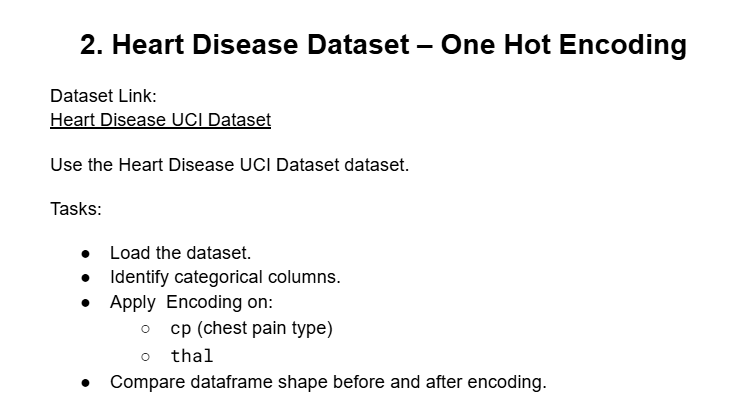

In [94]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [101]:
df = pd.read_csv("heart.csv")

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [96]:
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


In [97]:
print("Before Shape:", df.shape)

Before Shape: (1025, 14)


In [98]:
# Create encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

# Fit and transform
encoded_df = encoder.fit_transform(df[["cp", "thal"]])

# Add encoded columns
df = pd.concat([df, encoded_df], axis=1)

# Remove original columns
df = df.drop(["cp", "thal"], axis=1)


df.head()


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target,cp_0,cp_1,cp_2,cp_3,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212,0,1,168,0,1.0,2,2,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,0,155,1,3.1,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,1,125,1,2.6,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,1,161,0,0.0,2,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,1,106,0,1.9,1,3,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [99]:
print("After Shape:", df.shape)

After Shape: (1025, 20)


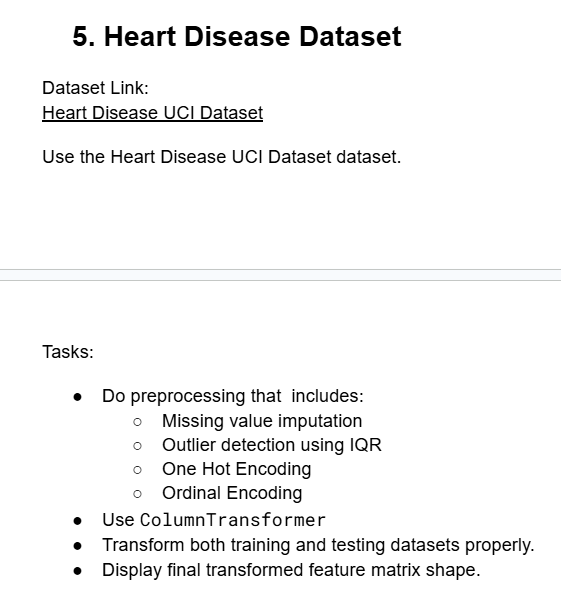

In [102]:
print(df.shape)

(1025, 14)


In [103]:
X = df.drop("target", axis=1)
y = df["target"]

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)